# p-Wert – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/p-wert)

> **Definition:** Der p-Wert gibt die Wahrscheinlichkeit an, dass das beobachtete
> Ergebnis **oder ein noch extremeres Ergebnis** eintritt, wenn die Nullhypothese wahr ist.

Vereinfacht: Der p-Wert beantwortet die Frage –
**„Wie wahrscheinlich ist mein Stichprobenergebnis, wenn H₀ gilt?"**

| p-Wert | Bedeutung | Entscheidung (α = 0,05) |
|---|---|---|
| p = 0,04 | 4 % Wahrscheinlichkeit unter H₀ | H₀ **ablehnen** (signifikant) |
| p = 0,20 | 20 % Wahrscheinlichkeit unter H₀ | H₀ **nicht ablehnen** |
| p < 0,01 | < 1 % | Hochsignifikant (\*\*) |
| p < 0,05 | < 5 % | Signifikant (\*) |
| p ≥ 0,05 | ≥ 5 % | Nicht signifikant (n.s.) |

**Wichtig:** Der p-Wert ist **keine** Wahrscheinlichkeit, dass H₀ wahr ist!

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm as norm_dist, t as t_dist

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Intuition: Was bedeutet der p-Wert?

**Beispiel (numiqo):** Gehalt von Männern und Frauen in Deutschland.

- H₀: Das Gehalt von Männern und Frauen **unterscheidet sich nicht**
- Stichprobe zeigt: Männer verdienen 150 € mehr als Frauen
- p-Wert = 0,04

**Interpretation:**
Wenn H₀ gilt (kein Unterschied in der Grundgesamtheit), ist es nur zu **4 %** wahrscheinlich,
eine Stichprobe zu ziehen, bei der das Gehalt um **150 € oder mehr** auseinanderliegt.

Da 4 % < 5 % (Signifikanzniveau α) → H₀ wird abgelehnt.

> **Analogie:** Stelle dir vor, du wirfst eine Münze 10 Mal und bekommst 9 Mal Kopf.
> Unter H₀ (faire Münze) ist das sehr unwahrscheinlich (p ≈ 1 %).
> Du zweifelst also an H₀.

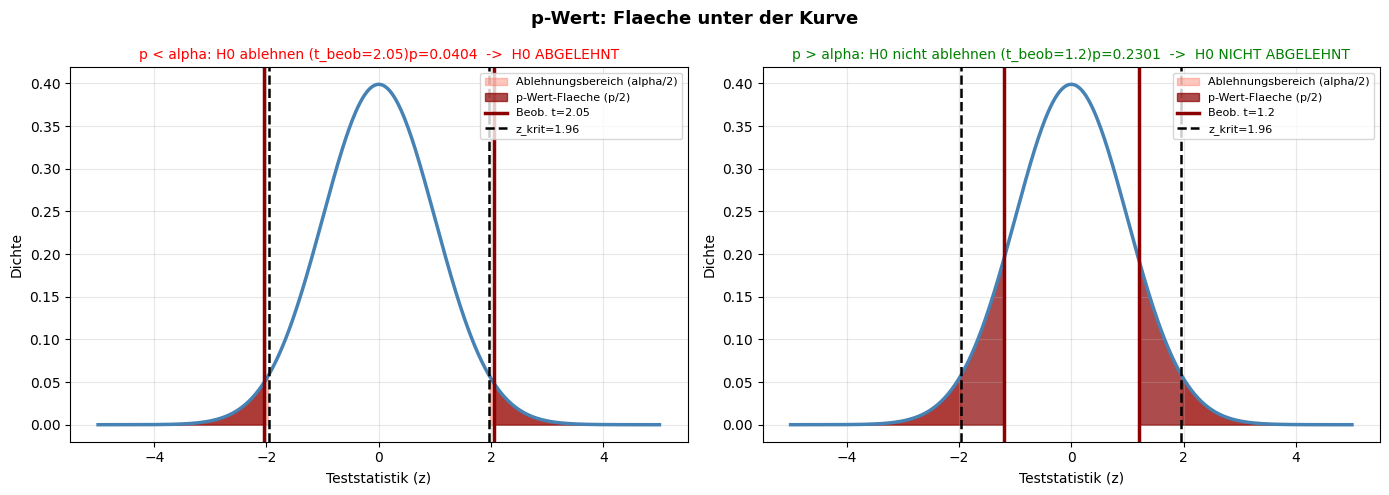

In [3]:
# Intuition: p-Wert als Fläche unter der Verteilungskurve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("p-Wert: Flaeche unter der Kurve", fontsize=13, fontweight="bold")

x = np.linspace(-5, 5, 500)
y = norm_dist.pdf(x, 0, 1)

for ax, t_beob, titel, alpha_v in zip(
    axes,
    [2.05, 1.2],
    ["p < alpha: H0 ablehnen (t_beob=2.05)", "p > alpha: H0 nicht ablehnen (t_beob=1.2)"],
    [0.05, 0.05]
):
    p_zwei = 2 * norm_dist.sf(abs(t_beob))
    z_krit = norm_dist.ppf(1 - alpha_v / 2)

    ax.plot(x, y, color="steelblue", linewidth=2.5)

    # Ablehnungsbereich (alpha)
    ax.fill_between(x[x >= z_krit],  y[x >= z_krit],
                    color="tomato", alpha=0.35, label="Ablehnungsbereich (alpha/2)")
    ax.fill_between(x[x <= -z_krit], y[x <= -z_krit],
                    color="tomato", alpha=0.35)

    # p-Wert-Flaeche (beobachtetes Ergebnis und extremere)
    ax.fill_between(x[x >= t_beob],  y[x >= t_beob],
                    color="darkred", alpha=0.7, label="p-Wert-Flaeche (p/2)")
    ax.fill_between(x[x <= -t_beob], y[x <= -t_beob],
                    color="darkred", alpha=0.7)

    ax.axvline( t_beob, color="darkred",  linestyle="-",  linewidth=2.5,
                label="Beob. t=" + str(t_beob))
    ax.axvline(-t_beob, color="darkred",  linestyle="-",  linewidth=2.5)
    ax.axvline( z_krit, color="black",    linestyle="--", linewidth=1.8,
                label="z_krit=" + str(round(z_krit, 3)))
    ax.axvline(-z_krit, color="black",    linestyle="--", linewidth=1.8)

    entsch = "H0 ABGELEHNT" if p_zwei < alpha_v else "H0 NICHT ABGELEHNT"
    farbe_txt = "red" if p_zwei < alpha_v else "green"
    ax.set_title(titel + "p=" + str(round(p_zwei, 4)) +
                 "  ->  " + entsch, color=farbe_txt, fontsize=10)
    ax.set_xlabel("Teststatistik (z)")
    ax.set_ylabel("Dichte")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Das numiqo-Beispiel: Gehaltsunterschied

**Schritt-für-Schritt durch das Gehalt-Beispiel:**

1. H₀: Männer und Frauen verdienen gleich viel (kein Unterschied)
2. Signifikanzniveau: α = 0,05
3. Stichprobe zeigt Unterschied von 150 €
4. p-Wert berechnen
5. p < α → H₀ ablehnen

Gehaltsunterschied: Männer vs. Frauen
n je Gruppe:         600
MW Männer:          3339.18 EUR
MW Frauen:           3270.42 EUR
Beobachtete Diff.:   68.76 EUR

t-Statistik:         1.5273
p-Wert (zweiseitig): 0.1270

p=0.1270 >= alpha=0.05  ->  H0 nicht ablehnen
Ergebnis: Kein signifikanter Gehaltsunterschied nachweisbar.


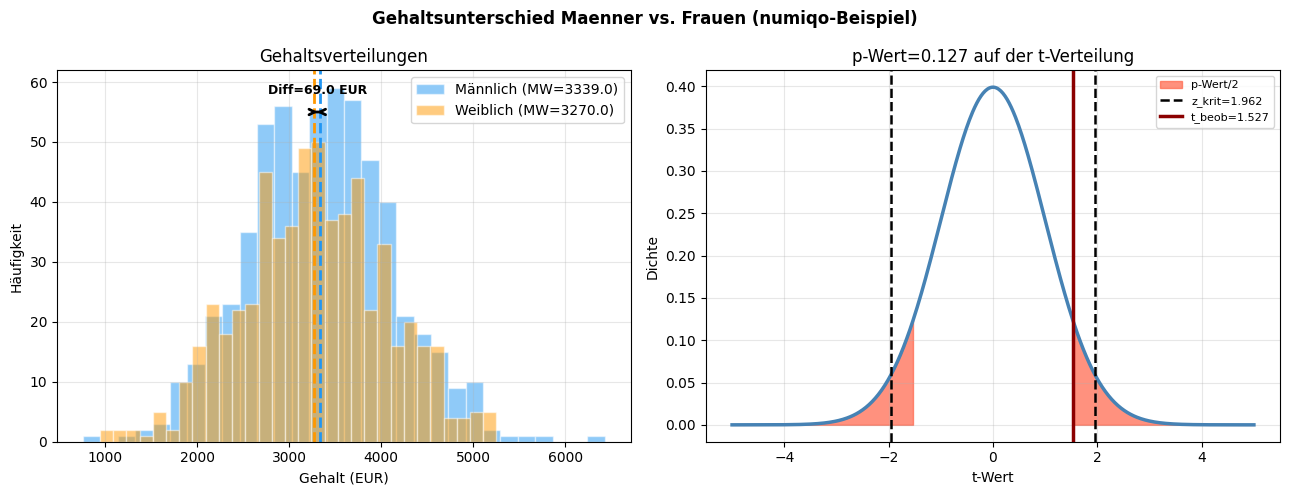

In [4]:
# numiqo-Beispiel: Gehaltsunterschied Männer vs. Frauen
np.random.seed(42)
n = 600
gehalt_m = pd.Series(np.random.normal(3350, 800, n))
gehalt_w = pd.Series(np.random.normal(3200, 780, n))

differenz = gehalt_m.mean() - gehalt_w.mean()

# t-Test
t_stat, p_zwei = stats.ttest_ind(gehalt_m, gehalt_w)
alpha = 0.05

print("Gehaltsunterschied: Männer vs. Frauen")
print(f"n je Gruppe:         {n}")
print(f"MW Männer:          {gehalt_m.mean():.2f} EUR")
print(f"MW Frauen:           {gehalt_w.mean():.2f} EUR")
print(f"Beobachtete Diff.:   {differenz:.2f} EUR")
print()
print(f"t-Statistik:         {t_stat:.4f}")
print(f"p-Wert (zweiseitig): {p_zwei:.4f}")
print()

if p_zwei < alpha:
    stern = "***" if p_zwei < 0.001 else ("**" if p_zwei < 0.01 else "*")
    print(f"p={p_zwei:.4f} < alpha={alpha}  ->  H0 ablehnen  {stern}")
    print("Ergebnis: Es gibt einen statistisch signifikanten Gehaltsunterschied.")
else:
    print(f"p={p_zwei:.4f} >= alpha={alpha}  ->  H0 nicht ablehnen")
    print("Ergebnis: Kein signifikanter Gehaltsunterschied nachweisbar.")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Gehaltsunterschied Maenner vs. Frauen (numiqo-Beispiel)",
             fontsize=12, fontweight="bold")

# Verteilungsplot
x_plot = np.linspace(500, 6000, 400)
for ax_idx, (daten, farbe, label) in enumerate([
    (gehalt_m, "#2196F3", "Männlich"),
    (gehalt_w, "#FF9800", "Weiblich")
]):
    axes[0].hist(daten, bins=30, color=farbe, alpha=0.5, edgecolor="white",
                 label=label + " (MW=" + str(round(daten.mean(), 0)) + ")")
axes[0].axvline(gehalt_m.mean(), color="#2196F3", linestyle="--", linewidth=2)
axes[0].axvline(gehalt_w.mean(), color="#FF9800", linestyle="--", linewidth=2)
axes[0].annotate("", xy=(gehalt_w.mean(), 55), xytext=(gehalt_m.mean(), 55),
                 arrowprops=dict(arrowstyle="<->", color="black", lw=2))
axes[0].text((gehalt_m.mean()+gehalt_w.mean())/2, 58,
             "Diff=" + str(round(differenz, 0)) + " EUR",
             ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Gehaltsverteilungen")
axes[0].set_xlabel("Gehalt (EUR)")
axes[0].set_ylabel("Häufigkeit")
axes[0].legend()
axes[0].grid(alpha=0.3)

# p-Wert auf t-Verteilung
df_val = 2*n - 2
t_range = np.linspace(-5, 5, 500)
y_t = t_dist.pdf(t_range, df=df_val)
axes[1].plot(t_range, y_t, color="steelblue", linewidth=2.5)
axes[1].fill_between(t_range[t_range >= abs(t_stat)],
                     y_t[t_range >= abs(t_stat)],
                     color="tomato", alpha=0.7, label="p-Wert/2")
axes[1].fill_between(t_range[t_range <= -abs(t_stat)],
                     y_t[t_range <= -abs(t_stat)],
                     color="tomato", alpha=0.7)
z_krit_v = t_dist.ppf(0.975, df=df_val)
axes[1].axvline( z_krit_v, color="black", linestyle="--", linewidth=1.8,
                label="z_krit=" + str(round(z_krit_v, 3)))
axes[1].axvline(-z_krit_v, color="black", linestyle="--", linewidth=1.8)
axes[1].axvline(t_stat, color="darkred", linestyle="-", linewidth=2.5,
                label="t_beob=" + str(round(t_stat, 3)))
axes[1].set_title("p-Wert=" + str(round(p_zwei, 4)) + " auf der t-Verteilung")
axes[1].set_xlabel("t-Wert")
axes[1].set_ylabel("Dichte")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Einseitiger vs. zweiseitiger p-Wert

| | Zweiseitig | Einseitig |
|---|---|---|
| Hypothese | Unterschied (egal in welche Richtung) | Gerichtete Hypothese (A > B) |
| Ablehnungsbereich | Beide Seiten (je α/2) | Nur eine Seite (α) |
| p-Wert | $p_{\text{zwei}}$ | $p_{\text{ein}} = p_{\text{zwei}} / 2$ |
| Wann? | Standard | Wenn Richtung vorab begründet |

**Umrechnung (numiqo):**
$$p_{\text{einseitig}} = \frac{p_{\text{zweiseitig}}}{2}$$

**Achtung:** Nur umrechnen, wenn der Effekt **in die erwartete Richtung** geht!
Geht er in die andere Richtung: $p_{\text{einseitig}} = 1 - p_{\text{zweiseitig}}/2$

**Beispiel (numiqo):** H₁: Reaktionszeit Gruppe A > Gruppe B
- p zweiseitig = 0,04
- Effekt geht in erwartete Richtung → p einseitig = 0,04 / 2 = **0,02**
- Effekt geht in entgegengesetzte Richtung → p einseitig = 1 - 0,02 = **0,98**

Einseitiger p-Wert: Reaktionszeit
H1: Gruppe A hat HÖHERE Reaktionszeit als Gruppe B

MW Gruppe A: 514.0 ms
MW Gruppe B: 488.6 ms
Richtung stimmt (A > B): True

t-Statistik:         1.8020
p zweiseitig:        0.0754
p einseitig:         0.0377  (= 0.0754 / 2)

p (zweiseitig  ) = 0.0754  ->  H0 nicht ablehnen n.s.
p (einseitig   ) = 0.0377  ->  H0 ablehnen *


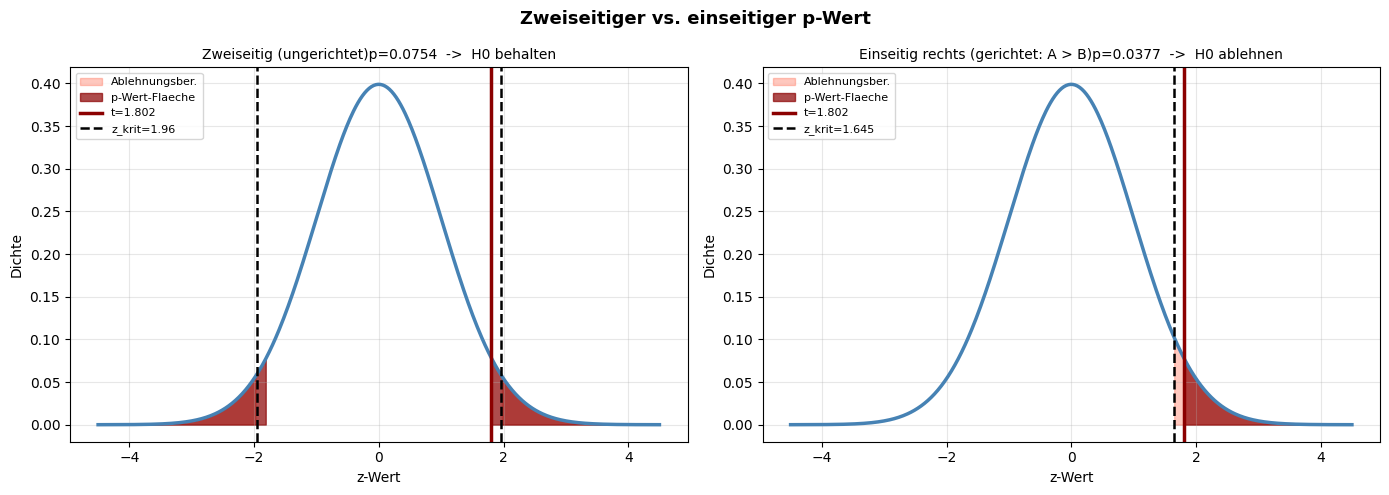

In [9]:
# Einseitiger vs. zweiseitiger p-Wert
np.random.seed(7)
reaktion_a = pd.Series(np.random.normal(520, 60, 40))
reaktion_b = pd.Series(np.random.normal(490, 58, 40))

t_stat_r, p_zwei_r = stats.ttest_ind(reaktion_a, reaktion_b)

# Einseitig: H1: Gruppe A hat GROESSERE Reaktionszeit als Gruppe B
# -> Richtung: t > 0 (A groesser als B)
richtung_ok = t_stat_r > 0
p_ein_r = p_zwei_r / 2 if richtung_ok else 1 - p_zwei_r / 2

print("Einseitiger p-Wert: Reaktionszeit")
print(f"H1: Gruppe A hat HÖHERE Reaktionszeit als Gruppe B")
print()
print(f"MW Gruppe A: {reaktion_a.mean():.1f} ms")
print(f"MW Gruppe B: {reaktion_b.mean():.1f} ms")
print(f"Richtung stimmt (A > B): {richtung_ok}")
print()
print(f"t-Statistik:         {t_stat_r:.4f}")
print(f"p zweiseitig:        {p_zwei_r:.4f}")
print(f"p einseitig:         {p_ein_r:.4f}  (= {p_zwei_r:.4f} / 2)")
print()

alpha = 0.05
for p_v, bezeichnung in [(p_zwei_r, "zweiseitig"), (p_ein_r, "einseitig")]:
    entsch = "H0 ablehnen" if p_v < alpha else "H0 nicht ablehnen"
    stern  = " ***" if p_v < 0.001 else (" **" if p_v < 0.01 else (" *" if p_v < 0.05 else " n.s."))
    print(f"p ({bezeichnung:<12}) = {p_v:.4f}  ->  {entsch}{stern}")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Zweiseitiger vs. einseitiger p-Wert", fontsize=13, fontweight="bold")

x_n = np.linspace(-4.5, 4.5, 500)
y_n = norm_dist.pdf(x_n, 0, 1)
z_krit_2 = norm_dist.ppf(0.975)
z_krit_1 = norm_dist.ppf(0.95)

for ax, titel, z_ab, p_v, seiten in zip(
    axes,
    ["Zweiseitig (ungerichtet)", "Einseitig rechts (gerichtet: A > B)"],
    [z_krit_2, z_krit_1],
    [p_zwei_r, p_ein_r],
    [2, 1]
):
    ax.plot(x_n, y_n, color="steelblue", linewidth=2.5)

    # Ablehnungsbereich
    ax.fill_between(x_n[x_n >= z_ab], y_n[x_n >= z_ab],
                    color="tomato", alpha=0.35, label="Ablehnungsber.")
    if seiten == 2:
        ax.fill_between(x_n[x_n <= -z_ab], y_n[x_n <= -z_ab],
                        color="tomato", alpha=0.35)

    # p-Wert-Flaeche
    t_abs = abs(t_stat_r)
    ax.fill_between(x_n[x_n >= t_abs], y_n[x_n >= t_abs],
                    color="darkred", alpha=0.7, label="p-Wert-Flaeche")
    if seiten == 2:
        ax.fill_between(x_n[x_n <= -t_abs], y_n[x_n <= -t_abs],
                        color="darkred", alpha=0.7)

    ax.axvline(t_abs,  color="darkred", linestyle="-",  linewidth=2.5,
               label="t=" + str(round(t_stat_r, 3)))
    ax.axvline(z_ab,   color="black",   linestyle="--", linewidth=1.8,
               label="z_krit=" + str(round(z_ab, 3)))
    if seiten == 2:
        ax.axvline(-z_ab, color="black", linestyle="--", linewidth=1.8)

    entsch = "H0 ablehnen" if p_v < 0.05 else "H0 behalten"
    ax.set_title(titel + "p=" + str(round(p_v, 4)) +
                 "  ->  " + entsch, fontsize=10)
    ax.set_xlabel("z-Wert")
    ax.set_ylabel("Dichte")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. p-Wert berechnen: Ablauf

Laut numiqo folgt die Berechnung diesen Schritten:

1. **Signifikanzniveau α festlegen** (z. B. 5 %)
2. **Statistischen Test wählen** (z. B. t-Test, Chi-Quadrat, ANOVA)
3. **Teststatistik berechnen** (z. B. t-Wert, F-Wert, χ²-Wert)
4. **p-Wert aus der Verteilung ermitteln**
5. **Entscheidung:** p < α → H₀ ablehnen

### Verteilungen für den p-Wert

| Test | Verteilung | Teststatistik |
|---|---|---|
| t-Test | t-Verteilung (df = n−1 bzw. n₁+n₂−2) | t-Wert |
| Chi-Quadrat-Test | χ²-Verteilung (df = (r−1)(c−1)) | χ²-Wert |
| ANOVA | F-Verteilung (df₁, df₂) | F-Wert |
| Pearson-Korrelation | t-Verteilung (df = n−2) | t-Wert |

p-Wert-Berechnung aus Teststatistiken

t-Test:           t=2.5, df=38
  p (zweiseitig) = 0.0169  -> signifikant *

Chi-Quadrat-Test: chi2=5.8, df=2
  p              = 0.0550  -> n.s.

ANOVA:            F=4.2, df1=2, df2=57
  p              = 0.0199  -> signifikant *



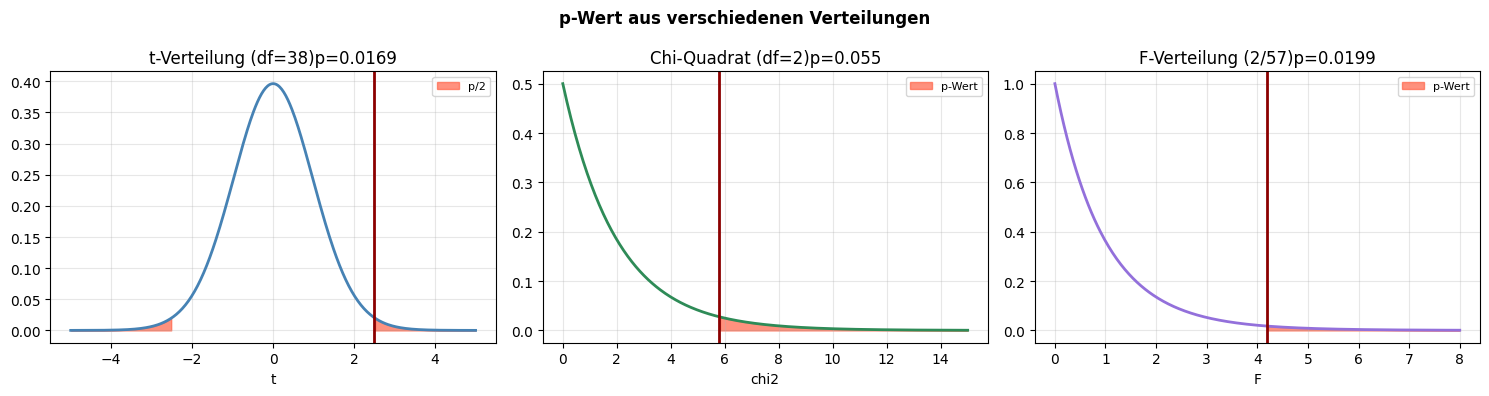

In [10]:
# p-Wert aus verschiedenen Verteilungen berechnen
from scipy.stats import t as t_dist, chi2, f as f_dist

print("p-Wert-Berechnung aus Teststatistiken")
print()

# t-Test: t=2.5, df=38
t_wert = 2.5
df_t   = 38
p_t    = 2 * t_dist.sf(abs(t_wert), df=df_t)
print(f"t-Test:           t={t_wert}, df={df_t}")
print(f"  p (zweiseitig) = {p_t:.4f}  -> {'signifikant *' if p_t < 0.05 else 'n.s.'}")
print()

# Chi-Quadrat: chi2=5.8, df=2
chi2_wert = 5.8
df_chi    = 2
p_chi     = chi2.sf(chi2_wert, df=df_chi)
print(f"Chi-Quadrat-Test: chi2={chi2_wert}, df={df_chi}")
print(f"  p              = {p_chi:.4f}  -> {'signifikant *' if p_chi < 0.05 else 'n.s.'}")
print()

# ANOVA: F=4.2, df1=2, df2=57
f_wert = 4.2
df1, df2 = 2, 57
p_f    = f_dist.sf(f_wert, df1, df2)
print(f"ANOVA:            F={f_wert}, df1={df1}, df2={df2}")
print(f"  p              = {p_f:.4f}  -> {'signifikant *' if p_f < 0.05 else 'n.s.'}")
print()

# Visualisierung der drei Verteilungen mit p-Wert-Flaechen
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("p-Wert aus verschiedenen Verteilungen", fontsize=12, fontweight="bold")

# t-Verteilung
x_t = np.linspace(-5, 5, 400)
y_tt = t_dist.pdf(x_t, df=df_t)
axes[0].plot(x_t, y_tt, color="steelblue", linewidth=2)
axes[0].fill_between(x_t[x_t >= t_wert],  y_tt[x_t >= t_wert],
                     color="tomato", alpha=0.7, label="p/2")
axes[0].fill_between(x_t[x_t <= -t_wert], y_tt[x_t <= -t_wert],
                     color="tomato", alpha=0.7)
axes[0].axvline(t_wert, color="darkred", linewidth=2)
axes[0].set_title("t-Verteilung (df=" + str(df_t) + ")p=" + str(round(p_t, 4)))
axes[0].set_xlabel("t")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Chi-Quadrat-Verteilung
x_c = np.linspace(0, 15, 400)
y_c = chi2.pdf(x_c, df=df_chi)
axes[1].plot(x_c, y_c, color="seagreen", linewidth=2)
axes[1].fill_between(x_c[x_c >= chi2_wert], y_c[x_c >= chi2_wert],
                     color="tomato", alpha=0.7, label="p-Wert")
axes[1].axvline(chi2_wert, color="darkred", linewidth=2)
axes[1].set_title("Chi-Quadrat (df=" + str(df_chi) + ")p=" + str(round(p_chi, 4)))
axes[1].set_xlabel("chi2")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# F-Verteilung
x_f = np.linspace(0, 8, 400)
y_f = f_dist.pdf(x_f, df1, df2)
axes[2].plot(x_f, y_f, color="mediumpurple", linewidth=2)
axes[2].fill_between(x_f[x_f >= f_wert], y_f[x_f >= f_wert],
                     color="tomato", alpha=0.7, label="p-Wert")
axes[2].axvline(f_wert, color="darkred", linewidth=2)
axes[2].set_title("F-Verteilung (" + str(df1) + "/" + str(df2) + ")p=" + str(round(p_f, 4)))
axes[2].set_xlabel("F")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Häufige Missverständnisse

| ❌ Falsche Interpretation | ✅ Richtige Interpretation |
|---|---|
| p = 0,03 bedeutet, H₀ ist zu 3 % wahr | p = 0,03 bedeutet: **Wenn H₀ gilt**, ist dieses Ergebnis zu 3 % wahrscheinlich |
| p = 0,06 → kein Unterschied | p = 0,06 → **kein Nachweis** eines Unterschieds bei α = 0,05 |
| Kleines p = großer Effekt | p hängt auch von n ab – großes n → kleines p, auch bei kleinen Effekten |
| p < 0,05 → H₁ bewiesen | p < 0,05 → H₀ abgelehnt – H₁ ist nur vorläufig gestützt |
| Grenze 0,04 vs. 0,06 = riesiger Unterschied | p = 0,04 und p = 0,06 sind inhaltlich kaum verschieden! |

> **numiqo:** Es ist ratsam, den **tatsächlichen p-Wert** anzugeben,
> nicht nur „signifikant / nicht signifikant".

## 6. p-Wert und Stichprobengröße

**Gleicher Effekt, unterschiedliche n → sehr unterschiedliche p-Werte!**

Das zeigt: Ein kleines p allein sagt nichts über die **praktische Relevanz** aus.
Immer auch die **Effektstärke** (z. B. Cohens d) berichten.

p-Wert in Abhaengigkeit von n (gleicher Effekt d=0.25)
     n      p-Wert    Signifikant?
    10    0.007850            ja *
    20    0.092831            nein
    50    0.142644            nein
   100    0.425979            nein
   200    0.006816            ja *
   500    0.000670            ja *
  1000    0.000001            ja *
  5000    0.000000            ja *


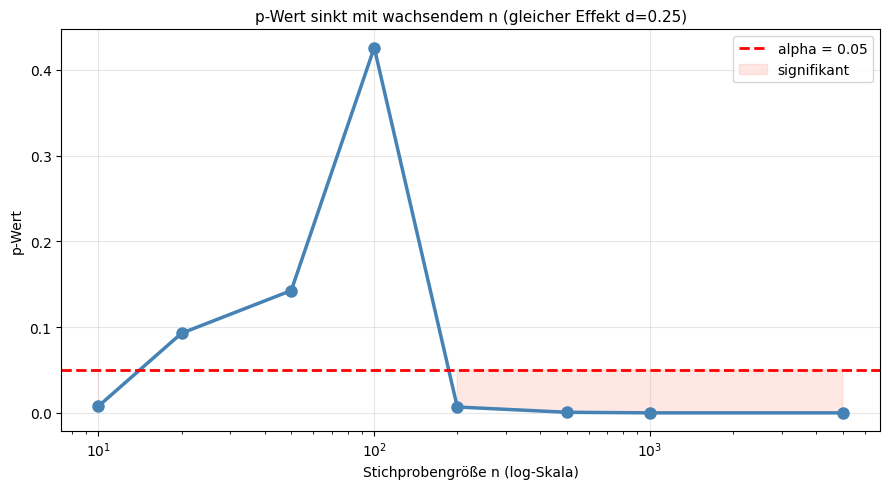

In [11]:
# p-Wert sinkt mit wachsendem n – gleicher Effekt
np.random.seed(42)
delta = 5        # fixer Mittelwertsunterschied
sigma = 20.0     # fixe Standardabweichung

n_werte = [10, 20, 50, 100, 200, 500, 1000, 5000]
p_werte = []
d_werte = []

for n_s in n_werte:
    g1 = np.random.normal(100,       sigma, n_s)
    g2 = np.random.normal(100+delta, sigma, n_s)
    _, p = stats.ttest_ind(g1, g2)
    d = delta / sigma           # Cohens d (konstant)
    p_werte.append(p)
    d_werte.append(d)

print("p-Wert in Abhaengigkeit von n (gleicher Effekt d=" + str(delta/sigma) + ")")
print(f"{'n':>6}  {'p-Wert':>10}  {'Signifikant?':>14}")
for n_s, p_v in zip(n_werte, p_werte):
    sig = "ja *" if p_v < 0.05 else "nein"
    print(f"{n_s:>6}  {p_v:>10.6f}  {sig:>14}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_werte, p_werte, "o-", color="steelblue", linewidth=2.5, markersize=8)
ax.axhline(0.05, color="red", linestyle="--", linewidth=2,
           label="alpha = 0.05")
ax.fill_between(n_werte, p_werte, 0.05,
                where=[p < 0.05 for p in p_werte],
                alpha=0.15, color="tomato", label="signifikant")
ax.set_xscale("log")
ax.set_title("p-Wert sinkt mit wachsendem n (gleicher Effekt d=" + str(round(delta/sigma, 2)) + ")",
             fontsize=11)
ax.set_xlabel("Stichprobengröße n (log-Skala)")
ax.set_ylabel("p-Wert")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Wie gibt man den p-Wert an?

**Empfehlung (numiqo):**
- Den **tatsächlichen p-Wert** angeben (nicht nur „signifikant / n.s.")
- Rundung: 2 signifikante Stellen sind üblich
- Sternchen-Notation ergänzend verwenden

### Sternchen-Notation

| Notation | Bedeutung |
|---|---|
| `***` | p < 0,001 (hochsignifikant) |
| `**` | p < 0,01 |
| `*` | p < 0,05 (signifikant) |
| `n.s.` | p ≥ 0,05 (nicht signifikant) |

### Schreibweise in wissenschaftlichen Texten
- `t(38) = 2.50, p = .042` (APA-Format)
- `t(38) = 2.50, p < .001`
- Nicht: ~~`p = 0.000`~~ → korrekt: `p < .001`

In [12]:
# Hilfsfunktion: p-Wert korrekt angeben
def p_stern(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "n.s."

def p_formatieren(p, stellen=4):
    if p < 0.001:
        return "p < .001"
    else:
        return "p = " + str(round(p, stellen)).replace("0.", ".")

# Demo
test_p_werte = [0.0003, 0.0045, 0.0390, 0.0420, 0.0501, 0.1820]

print("p-Wert korrekt angeben")
print(f"{'p-Wert':>10}  {'Stern':>6}  {'Formatiert':>12}  {'Entscheidung'}")

for p_v in test_p_werte:
    entsch = "H0 ablehnen" if p_v < 0.05 else "H0 nicht ablehnen"
    print(f"{p_v:>10.4f}  {p_stern(p_v):>6}  {p_formatieren(p_v):>12}  {entsch}")

print()
print("APA-Beispiele:")
print("  t(38) = 2.50, " + p_formatieren(0.017))
print("  t(38) = 4.12, " + p_formatieren(0.00018))
print("  chi2(2) = 1.84, " + p_formatieren(0.398) + " (n.s.)")

p-Wert korrekt angeben
    p-Wert   Stern    Formatiert  Entscheidung
    0.0003     ***      p < .001  H0 ablehnen
    0.0045      **     p = .0045  H0 ablehnen
    0.0390       *      p = .039  H0 ablehnen
    0.0420       *      p = .042  H0 ablehnen
    0.0501    n.s.     p = .0501  H0 nicht ablehnen
    0.1820    n.s.      p = .182  H0 nicht ablehnen

APA-Beispiele:
  t(38) = 2.50, p = .017
  t(38) = 4.12, p < .001
  chi2(2) = 1.84, p = .398 (n.s.)


## 8. Zusammenfassung

```
p-Wert – Übersicht
│
├── DEFINITION
│   Wahrscheinlichkeit, das beobachtete (oder extremere) Ergebnis
│   zu erhalten, WENN H0 wahr ist
│
├── ENTSCHEIDUNGSREGEL
│   p < alpha  ->  H0 ablehnen (signifikant)
│   p >= alpha ->  H0 nicht ablehnen (nicht signifikant)
│
├── SIGNIFIKANZSTUFEN
│   p <= 0.001  ->  *** hochsignifikant
│   p <= 0.01   ->  **  sehr signifikant
│   p <= 0.05   ->  *   signifikant
│   p >  0.05   ->  n.s. nicht signifikant
│
├── EINSEITIG vs. ZWEISEITIG
│   Zweiseitig:   Ablehnungsbereich auf beiden Seiten (je alpha/2)
│   Einseitig:    p_ein = p_zwei / 2  (nur wenn Richtung stimmt!)
│   Falsche Richtung: p_ein = 1 - p_zwei / 2
│
├── BERECHNUNG
│   1. Signifikanzniveau alpha festlegen
│   2. Passenden Test waehlen (t, chi2, F, ...)
│   3. Teststatistik berechnen
│   4. p-Wert aus Verteilung ablesen
│   5. p < alpha?
│
├── WICHTIGE EINSCHRAENKUNGEN
│   p ist NICHT die Wahrscheinlichkeit, dass H0 wahr ist
│   Grosses n -> kleines p (auch bei irrelevantem Effekt)
│   Immer Effektstaerke (Cohens d) zusaetzlich berichten
│   p knapp ueber/unter 0.05 sind inhaltlich kaum unterschiedlich
│
└── ANGABE
    Tatsächlichen p-Wert angeben (nicht nur signifikant/n.s.)
    Rundung: 2 signifikante Stellen
    Bei p < 0.001: "p < .001" schreiben
```

---
Quelle: [numiqo.de/tutorial/p-wert](https://numiqo.de/tutorial/p-wert)